# 🧮 Notebook 03 — Feature Engineering & Anomaly Detection

**Multimodal RCA Engine — Phase 1: Log Extraction & Processing**

This notebook covers:
1. Session/trace grouping by block ID and time windows
2. Event count vector construction
3. TF-IDF feature extraction from log content
4. Anomaly label alignment
5. Visualization (t-SNE/UMAP) of feature space
6. Baseline anomaly detection (Isolation Forest, LOF)

---

## 3.1 — Setup & Load Parsed Data

In [1]:
import sys
import os
from pathlib import Path

PROJECT_ROOT = Path(os.getcwd()).parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

from src.utils import PARSED_DIR, PROCESSED_DIR, FIGURES_DIR, RAW_DIR, ensure_directories, print_section, get_dataset_files
from src.feature_extractor import LogFeatureExtractor

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 12

ensure_directories()
print("✅ Setup complete!")

✅ All directories created successfully.
✅ Setup complete!


In [2]:
# Load parsed HDFS data from Notebook 02
hdfs_parsed_path = PARSED_DIR / 'hdfs_parsed.csv'

if hdfs_parsed_path.exists():
    hdfs_df = pd.read_csv(hdfs_parsed_path)
    print(f"📊 Loaded HDFS parsed data: {hdfs_df.shape}")
    print(f"   Columns: {list(hdfs_df.columns)}")
    display(hdfs_df.head())
else:
    print("❌ Parsed data not found. Please run Notebook 02 first.")
    print(f"   Expected: {hdfs_parsed_path}")

📊 Loaded HDFS parsed data: (100000, 8)
   Columns: ['date', 'time', 'pid', 'level', 'component', 'content', 'block_id', 'event_id']


,date,time,pid,level,component,content,block_id,event_id
0,81109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
1,81109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,2
2,81109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
3,81109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,1
4,81109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,3


## 3.2 — Session Grouping by Block ID

Each HDFS block operation generates multiple log entries. 
We group them by `block_id` to create **sessions** (traces).

In [3]:
extractor = LogFeatureExtractor()

# Filter rows with block_id and event_id
hdfs_with_blocks = hdfs_df.dropna(subset=['block_id', 'event_id']).copy()
hdfs_with_blocks['event_id'] = hdfs_with_blocks['event_id'].astype(int)

print(f"📊 Rows with block_id AND event_id: {len(hdfs_with_blocks):,}")

# Group by block_id
sessions = extractor.group_by_block_id(hdfs_with_blocks, block_id_col='block_id', event_col='event_id')

# Show session length distribution
session_lengths = [len(v) for v in sessions.values()]
print(f"\n📊 Session Statistics:")
print(f"   Total sessions:  {len(sessions):,}")
print(f"   Min length:      {min(session_lengths)}")
print(f"   Max length:      {max(session_lengths)}")
print(f"   Mean length:     {np.mean(session_lengths):.1f}")
print(f"   Median length:   {np.median(session_lengths):.0f}")

📊 Rows with block_id AND event_id: 100,000
📊 Created 7,940 sessions from block IDs

📊 Session Statistics:
   Total sessions:  7,940
   Min length:      1
   Max length:      249
   Mean length:     12.6
   Median length:   13


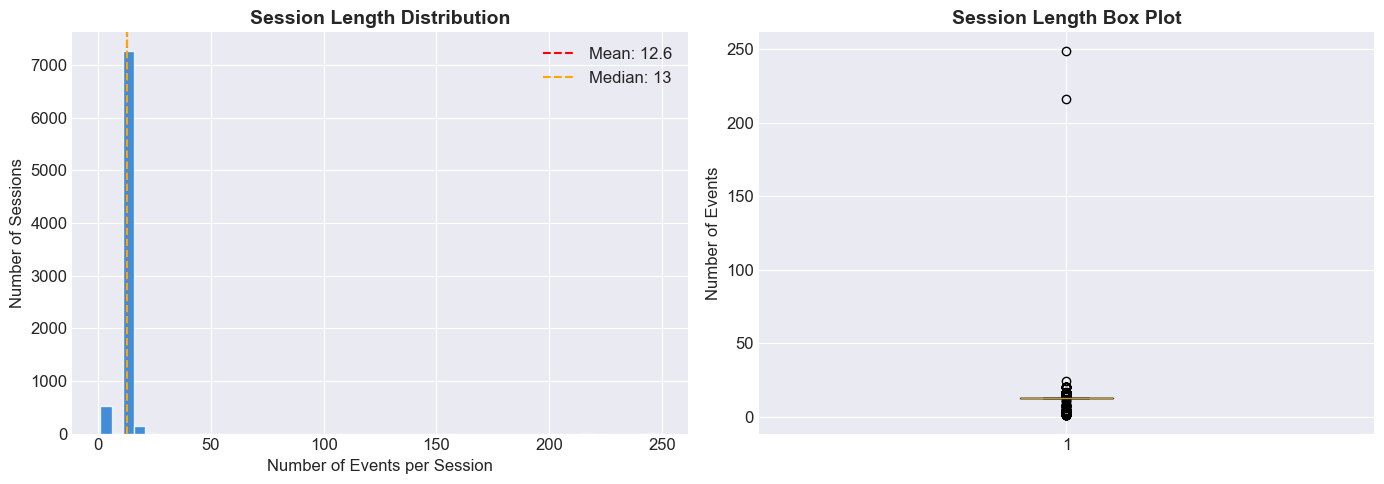

In [4]:
# === Session Length Distribution ===
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.hist(session_lengths, bins=50, color='#1976D2', edgecolor='white', alpha=0.8)
ax1.axvline(np.mean(session_lengths), color='red', linestyle='--', label=f'Mean: {np.mean(session_lengths):.1f}')
ax1.axvline(np.median(session_lengths), color='orange', linestyle='--', label=f'Median: {np.median(session_lengths):.0f}')
ax1.set_xlabel('Number of Events per Session')
ax1.set_ylabel('Number of Sessions')
ax1.set_title('Session Length Distribution', fontsize=14, fontweight='bold')
ax1.legend()

# Box plot
ax2.boxplot(session_lengths, vert=True)
ax2.set_ylabel('Number of Events')
ax2.set_title('Session Length Box Plot', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(str(FIGURES_DIR / '03_session_length_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

## 3.3 — Event Count Vectors

In [5]:
# Build event count matrix
event_count_df, session_ids = extractor.build_event_count_matrix(sessions)

print(f"\n📊 Event Count Matrix:")
display(event_count_df.head(10))

# Basic stats on event types
print(f"\n📊 Event Type Statistics:")
print(f"   Events present in all sessions: {(event_count_df > 0).all(axis=0).sum()}")
print(f"   Events present in <10% sessions: {((event_count_df > 0).mean(axis=0) < 0.1).sum()}")

📊 Event count matrix: 7940 sessions × 20 event types

📊 Event Count Matrix:


,E1,E2,E3,E4,E5,E6,E7,E8,E9,E10,E11,E12,E13,E14,E15,E16,E17,E18,E19,E20
session_id,,,,,,,,,,,,,,,,,,,,
blk_-1001553972418305662,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1010952805175971965,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1011482868748761910,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1011537904811654030,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1015291919896450721,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1015509325698227016,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1016552847214332937,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1017450244660796320,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
blk_-1018108268208665701,3,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0



📊 Event Type Statistics:
   Events present in all sessions: 1
   Events present in <10% sessions: 15


## 3.4 — Load Anomaly Labels

In [6]:
# Find anomaly labels — files are extracted flat into data/raw/
hdfs_files = get_dataset_files('hdfs_v1')
label_files = hdfs_files.get('label_files', []) if hdfs_files else []

# Also search in raw dir and preprocessed subdir
if not label_files:
    for search_dir in [RAW_DIR, RAW_DIR / 'preprocessed']:
        if search_dir.exists():
            for f in search_dir.iterdir():
                if 'anomaly' in f.name.lower() and f.suffix in ['.csv', '.txt']:
                    label_files.append(f)

print(f"Label files found: {[f.name for f in label_files]}")

if label_files:
    # Prefer CSV over TXT
    csv_labels = [f for f in label_files if f.suffix == '.csv']
    label_file = csv_labels[0] if csv_labels else label_files[0]
    labels_dict = LogFeatureExtractor.load_hdfs_labels(label_file)
    
    # Align with features
    X_aligned, y_aligned = LogFeatureExtractor.align_features_and_labels(event_count_df, labels_dict)
    
    print(f"\n📊 Final Dataset:")
    print(f"   Features shape: {X_aligned.shape}")
    print(f"   Labels shape:   {y_aligned.shape}")
    print(f"   Class balance:  {Counter(y_aligned)}")
else:
    print("❌ No label file found.")

Label files found: ['anomaly_label.csv', 'anomaly_labels.txt']
📊 Labels loaded: 558,223 normal, 16,838 anomaly (2.9%)
📊 Aligned: 7,940 sessions with both features and labels
   Normal:  7,627
   Anomaly: 313

📊 Final Dataset:
   Features shape: (7940, 20)
   Labels shape:   (7940,)
   Class balance:  Counter({0: 7627, 1: 313})


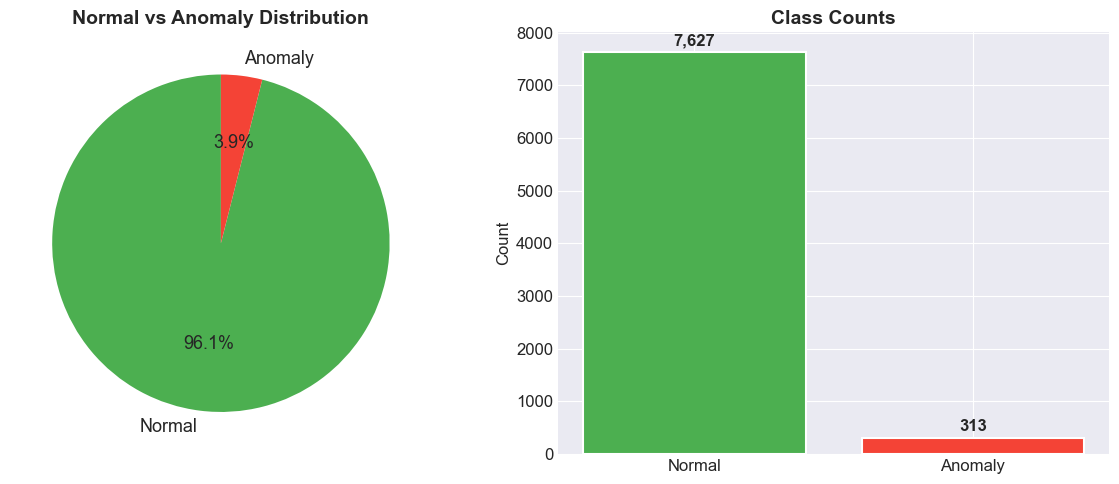

In [7]:
# === Class Distribution Visualization ===
if 'y_aligned' in dir():
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    
    counts = Counter(y_aligned)
    labels_str = ['Normal', 'Anomaly']
    values = [counts.get(0, 0), counts.get(1, 0)]
    colors = ['#4CAF50', '#F44336']
    
    ax1.pie(values, labels=labels_str, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 13})
    ax1.set_title('Normal vs Anomaly Distribution', fontsize=14, fontweight='bold')
    
    bars = ax2.bar(labels_str, values, color=colors, edgecolor='white', linewidth=1.5)
    for bar, val in zip(bars, values):
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(values)*0.01,
                 f'{val:,}', ha='center', va='bottom', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count')
    ax2.set_title('Class Counts', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '03_class_distribution.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 3.5 — Dimensionality Reduction & Visualization (t-SNE)


════════════════════════════════════════════════════════════
  t-SNE Visualization
════════════════════════════════════════════════════════════

   Subsampled to 5000 points for visualization


c:\Users\Fulchany NANITH\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\manifold\_t_sne.py:1162: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


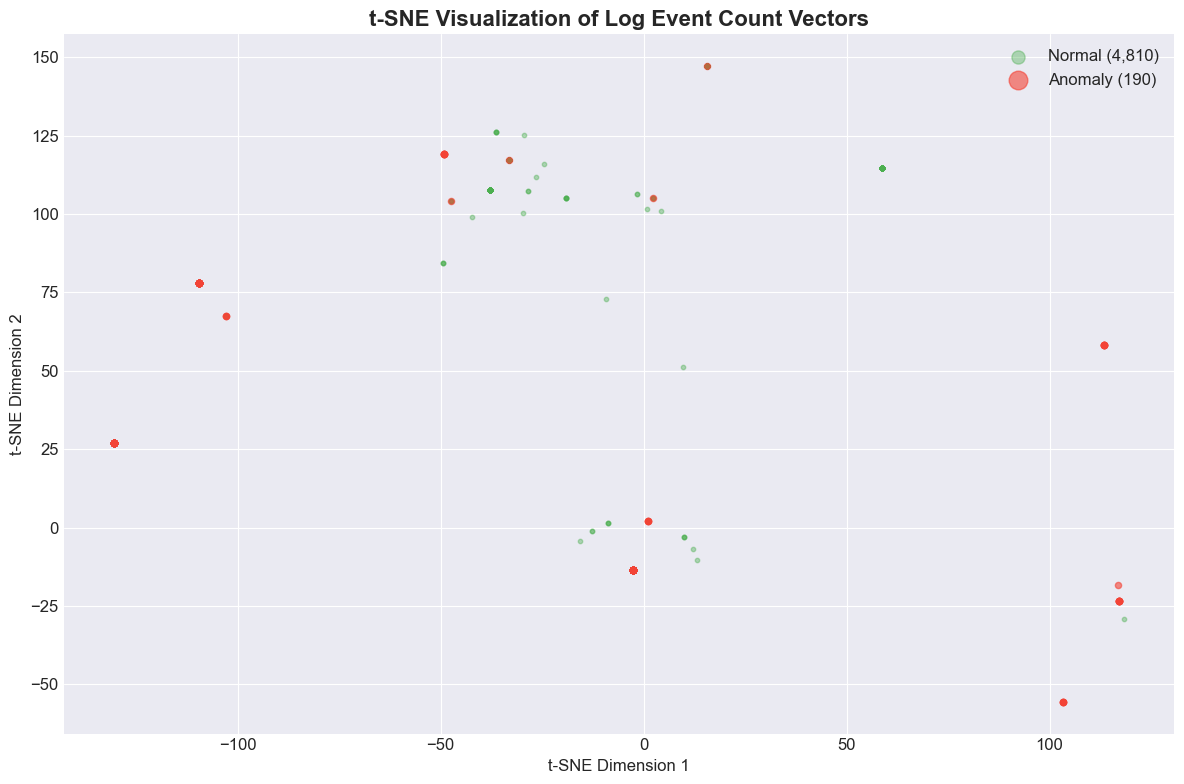

💾 Saved: results/figures/03_tsne_visualization.png


In [8]:
from sklearn.manifold import TSNE

if 'X_aligned' in dir() and len(X_aligned) > 0:
    print_section("t-SNE Visualization")
    
    # Subsample if dataset is large
    MAX_SAMPLES = 5000
    if len(X_aligned) > MAX_SAMPLES:
        np.random.seed(42)
        idx = np.random.choice(len(X_aligned), MAX_SAMPLES, replace=False)
        X_vis = X_aligned.iloc[idx].values
        y_vis = y_aligned[idx]
        print(f"   Subsampled to {MAX_SAMPLES} points for visualization")
    else:
        X_vis = X_aligned.values
        y_vis = y_aligned
    
    # Standardize
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_vis)
    
    # t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    X_tsne = tsne.fit_transform(X_scaled)
    
    # Plot
    fig, ax = plt.subplots(figsize=(12, 8))
    
    scatter_normal = ax.scatter(X_tsne[y_vis == 0, 0], X_tsne[y_vis == 0, 1],
                                c='#4CAF50', alpha=0.4, s=10, label=f'Normal ({(y_vis==0).sum():,})')
    scatter_anomaly = ax.scatter(X_tsne[y_vis == 1, 0], X_tsne[y_vis == 1, 1],
                                 c='#F44336', alpha=0.6, s=20, label=f'Anomaly ({(y_vis==1).sum():,})')
    
    ax.set_xlabel('t-SNE Dimension 1', fontsize=12)
    ax.set_ylabel('t-SNE Dimension 2', fontsize=12)
    ax.set_title('t-SNE Visualization of Log Event Count Vectors', fontsize=16, fontweight='bold')
    ax.legend(fontsize=12, markerscale=3)
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '03_tsne_visualization.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print("💾 Saved: results/figures/03_tsne_visualization.png")

## 3.6 — Baseline Anomaly Detection

We test two unsupervised anomaly detection methods as baselines:
1. **Isolation Forest** — Tree-based anomaly isolation
2. **Local Outlier Factor (LOF)** — Density-based detection

In [9]:
if 'X_aligned' in dir() and 'y_aligned' in dir():
    print_section("Baseline Anomaly Detection")
    
    # Prepare data
    X = X_aligned.values.astype(float)
    y_true = y_aligned
    
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    # Estimate contamination ratio
    contamination = (y_true == 1).sum() / len(y_true)
    contamination = min(max(contamination, 0.01), 0.5)  # Clamp
    print(f"   Estimated contamination: {contamination:.3f}")
    
    results = {}


════════════════════════════════════════════════════════════
  Baseline Anomaly Detection
════════════════════════════════════════════════════════════

   Estimated contamination: 0.039


In [10]:
# === Isolation Forest ===
if 'X_scaled' in dir():
    print_section("Isolation Forest")
    
    iso_forest = IsolationForest(
        contamination=contamination,
        random_state=42,
        n_estimators=200,
        max_samples='auto'
    )
    
    y_pred_iso = iso_forest.fit_predict(X_scaled)
    y_pred_iso = (y_pred_iso == -1).astype(int)  # Convert: -1 (anomaly) -> 1
    
    print("📊 Isolation Forest Results:")
    print(classification_report(y_true, y_pred_iso, target_names=['Normal', 'Anomaly']))
    
    f1 = f1_score(y_true, y_pred_iso)
    results['Isolation Forest'] = {'f1': f1, 'predictions': y_pred_iso}


════════════════════════════════════════════════════════════
  Isolation Forest
════════════════════════════════════════════════════════════

📊 Isolation Forest Results:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98      7627
     Anomaly       0.48      0.41      0.44       313

    accuracy                           0.96      7940
   macro avg       0.73      0.69      0.71      7940
weighted avg       0.96      0.96      0.96      7940



In [11]:
# === Local Outlier Factor ===
if 'X_scaled' in dir():
    print_section("Local Outlier Factor (LOF)")
    
    lof = LocalOutlierFactor(
        contamination=contamination,
        n_neighbors=20,
        novelty=False
    )
    
    y_pred_lof = lof.fit_predict(X_scaled)
    y_pred_lof = (y_pred_lof == -1).astype(int)
    
    print("📊 LOF Results:")
    print(classification_report(y_true, y_pred_lof, target_names=['Normal', 'Anomaly']))
    
    f1 = f1_score(y_true, y_pred_lof)
    results['LOF'] = {'f1': f1, 'predictions': y_pred_lof}


════════════════════════════════════════════════════════════
  Local Outlier Factor (LOF)
════════════════════════════════════════════════════════════

📊 LOF Results:
              precision    recall  f1-score   support

      Normal       0.96      1.00      0.98      7627
     Anomaly       0.35      0.05      0.09       313

    accuracy                           0.96      7940
   macro avg       0.66      0.52      0.53      7940
weighted avg       0.94      0.96      0.94      7940



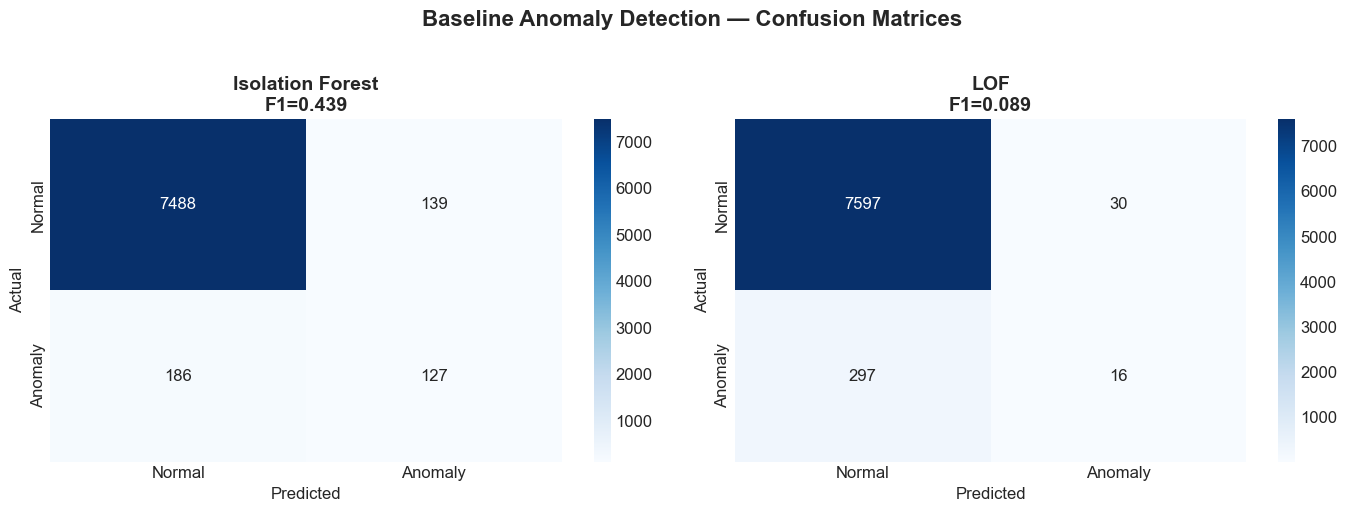

In [12]:
# === Confusion Matrices ===
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5))
    if len(results) == 1:
        axes = [axes]
    
    for ax, (name, res) in zip(axes, results.items()):
        cm = confusion_matrix(y_true, res['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                    xticklabels=['Normal', 'Anomaly'],
                    yticklabels=['Normal', 'Anomaly'])
        ax.set_xlabel('Predicted', fontsize=12)
        ax.set_ylabel('Actual', fontsize=12)
        ax.set_title(f'{name}\nF1={res["f1"]:.3f}', fontsize=14, fontweight='bold')
    
    plt.suptitle('Baseline Anomaly Detection — Confusion Matrices', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '03_baseline_confusion_matrices.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 3.7 — Event-Anomaly Correlation Heatmap

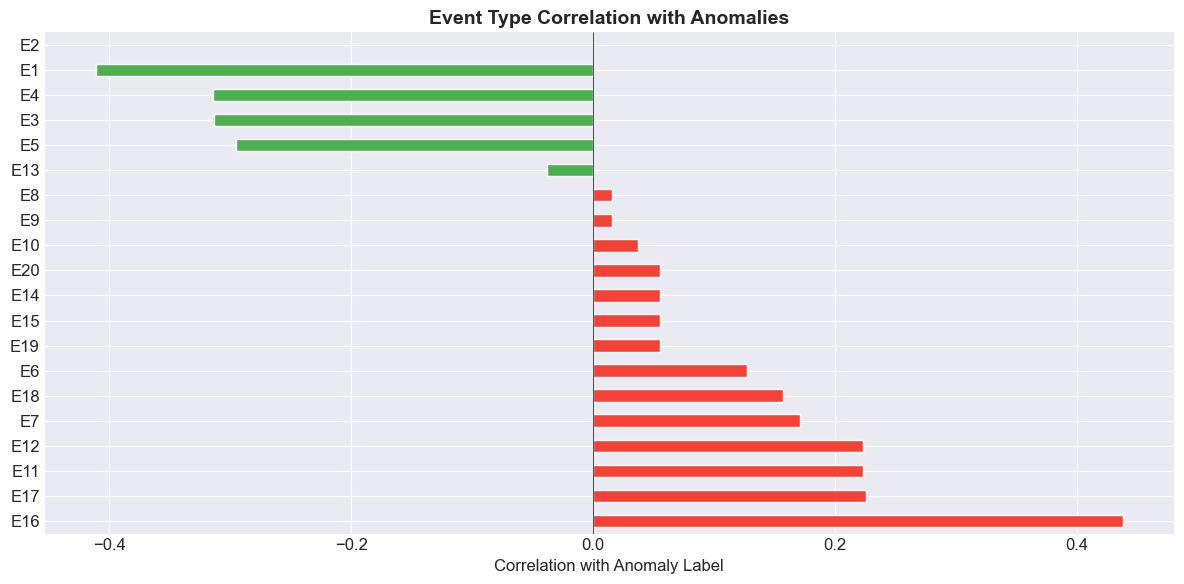

In [13]:
if 'X_aligned' in dir() and 'y_aligned' in dir():
    # Compute correlation between each event type and anomaly label
    corr_data = X_aligned.copy()
    corr_data['anomaly'] = y_aligned
    
    correlations = corr_data.corr()['anomaly'].drop('anomaly').sort_values(ascending=False)
    
    # Plot top correlated events
    fig, ax = plt.subplots(figsize=(12, 6))
    
    top_n = min(20, len(correlations))
    top_corr = pd.concat([correlations.head(top_n // 2), correlations.tail(top_n // 2)])
    
    colors = ['#F44336' if v > 0 else '#4CAF50' for v in top_corr.values]
    top_corr.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
    
    ax.set_xlabel('Correlation with Anomaly Label', fontsize=12)
    ax.set_title('Event Type Correlation with Anomalies', fontsize=14, fontweight='bold')
    ax.axvline(0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.savefig(str(FIGURES_DIR / '03_event_anomaly_correlation.png'), dpi=150, bbox_inches='tight')
    plt.show()

## 3.8 — Save Processed Features

In [14]:
if 'X_aligned' in dir():
    # Save feature matrix with labels
    features_with_labels = X_aligned.copy()
    features_with_labels['label'] = y_aligned
    
    output_path = PROCESSED_DIR / 'hdfs_features.csv'
    features_with_labels.to_csv(output_path)
    print(f"💾 Saved: {output_path}")
    
    # Save baseline results
    if results:
        baseline_df = pd.DataFrame({
            'method': list(results.keys()),
            'f1_score': [r['f1'] for r in results.values()]
        })
        baseline_path = PROCESSED_DIR / 'baseline_results.csv'
        baseline_df.to_csv(baseline_path, index=False)
        print(f"💾 Saved: {baseline_path}")
        display(baseline_df)

print("\n✅ All processed features saved!")

💾 Saved: d:\multimodal-rca-engine\data\processed\hdfs_features.csv
💾 Saved: d:\multimodal-rca-engine\data\processed\baseline_results.csv


,method,f1_score
0,Isolation Forest,0.438687
1,LOF,0.089136



✅ All processed features saved!


## 3.9 — Summary & Next Steps

### ✅ What we accomplished:
- Grouped logs into sessions by HDFS block ID
- Built event count feature vectors
- Loaded and aligned anomaly labels
- Visualized feature space with t-SNE
- Established baselines with Isolation Forest and LOF
- Analyzed event-anomaly correlations

### 📊 Baseline Results:
These unsupervised methods provide a **lower bound** for anomaly detection performance.
The LLM-based approach (Notebook 04) aims to significantly improve upon these baselines
by understanding the *semantic meaning* of log sequences.

### ➡️ Next: Notebook 04 — LLM Semantic Analysis
We'll prepare prompts for LLM-based log analysis and root cause identification.